# Relatório de EDA: Dados de Churn

### Objetivo

Avaliar fatores que impactam na probabilidade de churn dos clientes

### Dados

* CustomerID - Index, identifica o cliente
* Gender - Genero do cliente
* SeniorCitizen - Se o cliente é idoso ou não
* Partner - Se o cliente possui parceiro(a)
* Dependents - Se o cliente possui dependentes
* tenure - Número de meses que o cliente permaneceu com a empresa
* PhoneService - Se o cliente contratou serviço de telefonia
* MultipleLines - Se o cliente possui múltiplas linhas
* InternetService - Se o cliente contratou serviço de internet e se ele contratou serviço de internet
* OnlineSecurity - Se o cliente contratou segurança online
* OnlineBackup - Se o cliente contratou backup online
* DeviceProtection - Se o cliente contratou proteção de dispositivos
* TechSupport - Se o cliente contratou suporte técnico
* StreamingTV - Se o cliente contratou streaming de TV
* StreamingMovies - Se o cliente contratou streaming de filmes
* Contract - O prazo do contrato do cliente
* PaperlessBilling - Se o cliente optou por faturamento sem papel
* PaymentMethod - O método de pagamento do cliente
* MonthlyCharges - O valor cobrado do cliente mensalmente
* TotalCharges - O valor total cobrado do cliente
* Churn - Se o cliente encerrou o serviço (churn), variável alvo

### Resultados

In [2]:
# importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Carregar banco de dados
full_data = pd.read_excel('data/raw_data.xlsx', index_col='customerID')
# mostrar um pedaço do df
full_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
3325-['N' 'S' 'A' 'U' 'G'],Female,0,Yes,No,61,Yes,No,Fiber optic,No internet service,No,No internet service,No,No,No,Month-to-month,Yes,Mailed check,82.76,5045.65,No
3329-['L' 'E' 'Q' 'M' 'H'],Male,0,Yes,No,8,No,No phone service,Fiber optic,No,Yes,No,Yes,No,No,Month-to-month,Yes,Electronic check,56.44,445.25,Yes
6955-['P' 'W' 'Q' 'D' 'X'],Male,0,Yes,No,41,Yes,No,DSL,No,No,No,No,Yes,No,Two year,No,Mailed check,97.57,3995.44,Yes
1409-['S' 'L' 'G' 'M' 'D'],Male,1,Yes,No,46,Yes,No,DSL,No,No internet service,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),110.33,5087.22,No
9364-['M' 'J' 'O' 'G' 'Z'],Female,0,Yes,No,33,Yes,No,DSL,No,No,No internet service,No,Yes,No,Two year,Yes,Credit card (automatic),63.35,2101.75,No


In [4]:
# Verificando o tipo de cada feature
full_data.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Apenas features 'tenure', 'MonthlyCharges', 'TotalCharges' e SeniorCitizen são numéricas (int ou float), com todas as restantes sendo strings. A feature SeniorCitizen é numérica mesmo sendo, categórica porque ela já esta codificada em binário.

In [5]:
# calculando frequência de valores vazios nos dados
full_data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Não há nenhum valor nulo no banco em nenhuma das features, portanto tratamento de nulos não será nescessário.

In [6]:
# Verificando o número de valores únicos por feature
for i in list(full_data):
    print(i,' : ',full_data[i].nunique())

gender  :  2
SeniorCitizen  :  2
Partner  :  2
Dependents  :  2
tenure  :  73
PhoneService  :  2
MultipleLines  :  3
InternetService  :  3
OnlineSecurity  :  3
OnlineBackup  :  3
DeviceProtection  :  3
TechSupport  :  3
StreamingTV  :  3
StreamingMovies  :  3
Contract  :  3
PaperlessBilling  :  2
PaymentMethod  :  4
MonthlyCharges  :  5060
TotalCharges  :  6950
Churn  :  2


Apenas as features 'tenure', 'MonthlyCharges' e 'TotalCharges' possuem um alto númeto de valores únicos, podemos concluir então que elas são númericas, enquantos as outras são categóricas.

In [7]:
# Separando as features em listas de features numericas e categoricas
continous = ['tenure','MonthlyCharges','TotalCharges']
categorical = ['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines',
 'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
 'Contract','PaperlessBilling','PaymentMethod']

In [8]:
# resumo das features numéricas
full_data[continous].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,36.128070,70.022419,2531.331975
std,20.888903,28.995621,1902.292990
min,0.000000,20.020000,0.000000
25%,18.000000,45.080000,1011.235000
50%,36.000000,70.310000,2078.220000
75%,54.000000,95.250000,3726.085000
max,72.000000,119.950000,8623.970000


Pelos resumos podemos ver que, em média, os clientes ficam na empresa por 36 meses, e que o banco inclue clientes novos, com algues tendo um tenure de 0 meses. O pagamento mensal varia entre 20.02 e 119.95, em média ficando em 70.02. Os pagamentos totais ficaram no máximo em 8624.0, mas em média em 2531.3.

In [9]:
# Frequência da variável alvo
full_data['Churn'].value_counts(normalize=True)

Churn
No     0.648445
Yes    0.351555
Name: proportion, dtype: float64

Na base, 35.2%, um pouco mais de um terço, realizou o churn, podemos dizer então que classes resposta são relativamente bem baleaceadas, com o 'Não' sendo duas vezes mais frequênte.

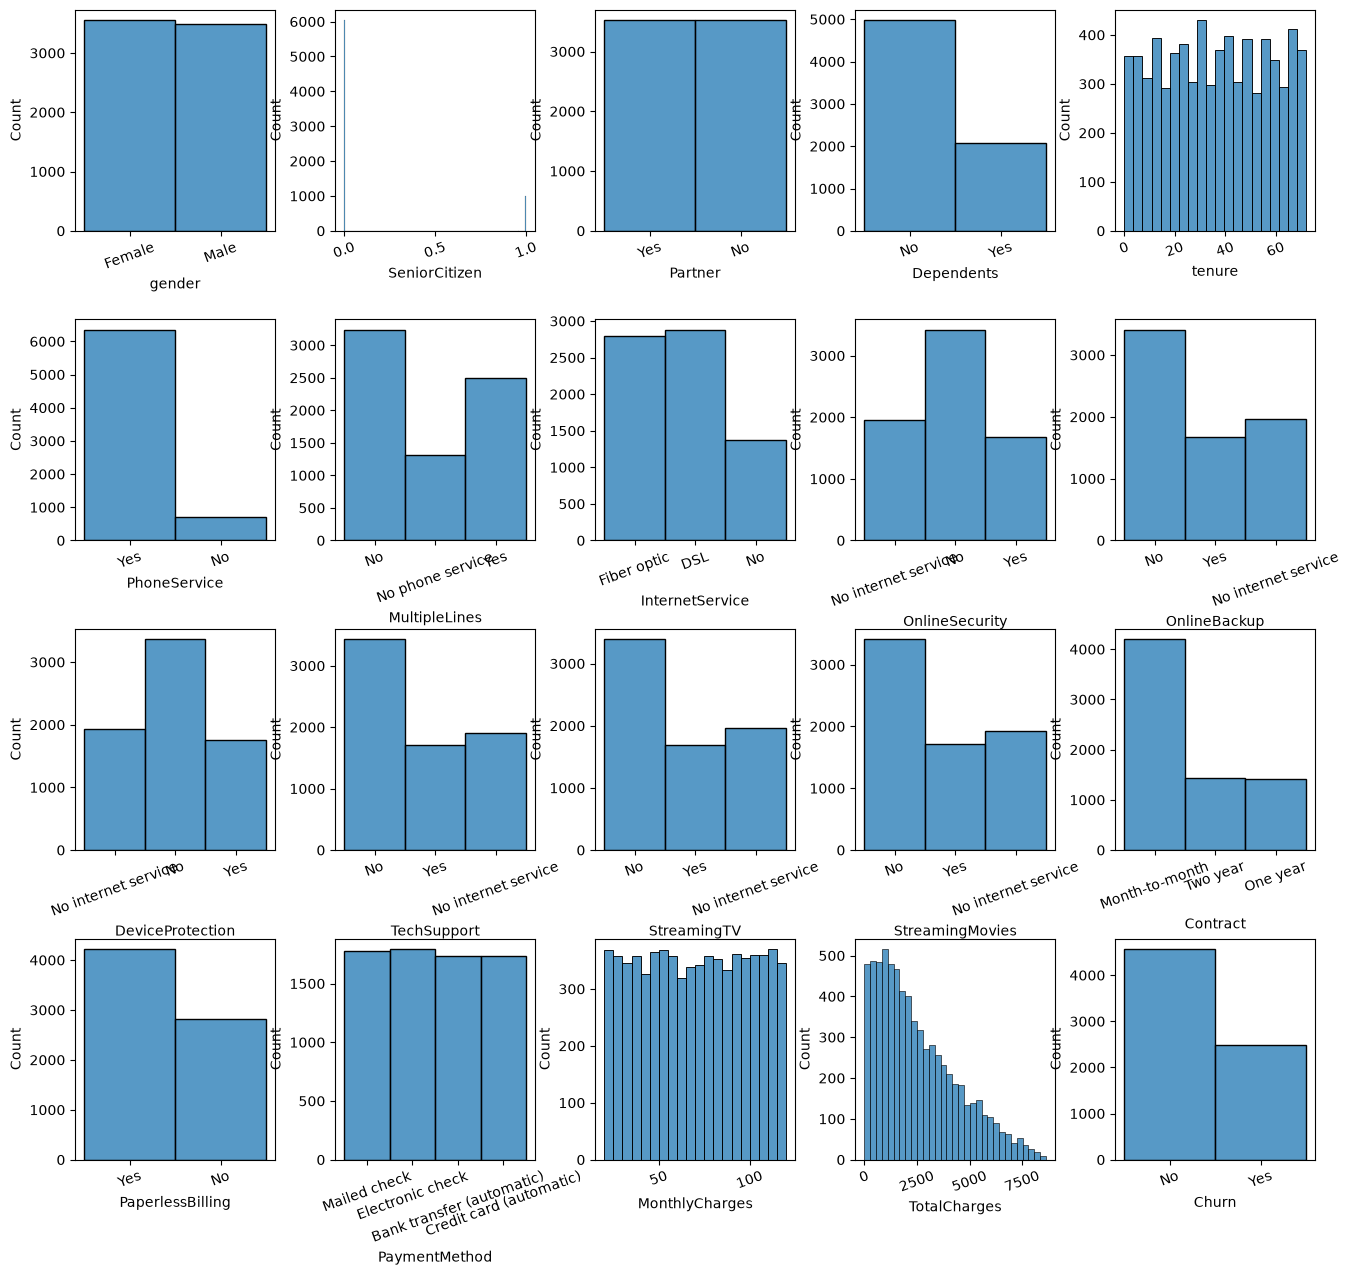

In [10]:
# Plotando o gráfico de todas as features
fig, ax = plt.subplots(4, 5, figsize=(16, 10))
plt.subplots_adjust(left=None, bottom=0.05, right=None, top=1.2, wspace=0.3, hspace=0.4)
for variable, subplot in zip(full_data.columns, ax.flatten()):
    plot = sns.histplot(full_data[variable], ax=subplot)
    plt.setp(plot.get_xticklabels(), rotation=20)

Com esses gráficos, podemos ver que, entre as váriaveis numéricas, 'tenure' e 'MonthlyCharges' são relativamente uniformemente distribuidas no intervalo da amostra, enquanto 'TotalCharges' tem uma distribuição assimétrica a direita. Para as features 'Gender' e 'Partner' as duas classes são praticamente iguais, enquanto para 'SeniorCitizen' e 'Dependents' o não domina, e para 'PaperlessBilling' e 'PhoneService' o sim domina.

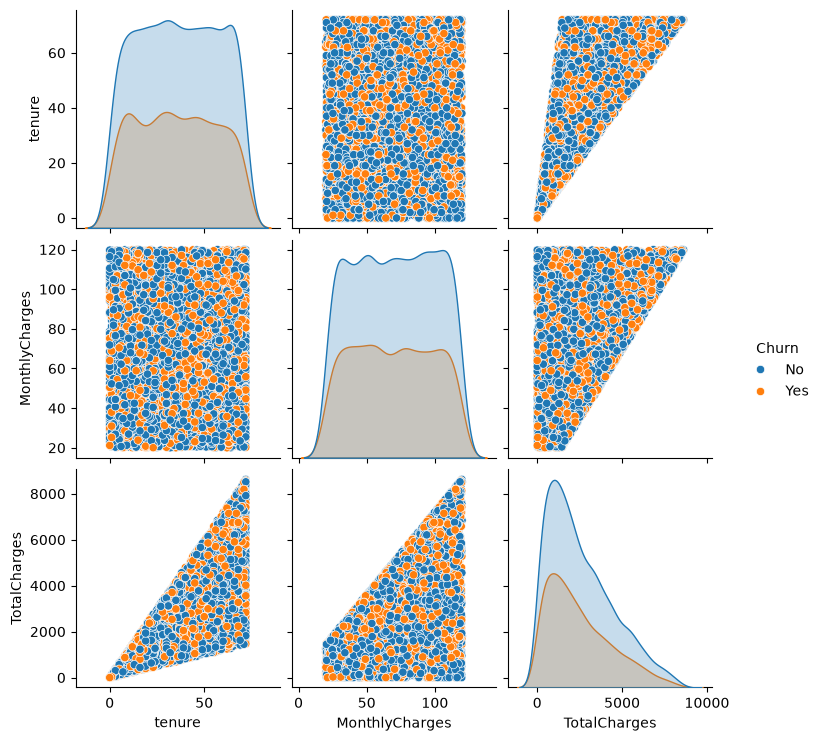

In [11]:
# Plotando correlação entre variáveis numéricas 
sns.pairplot(data = full_data.drop('SeniorCitizen', axis=1), hue='Churn')
plt.show()

Pelos gráficos de correlação, podemos perceber uma relação semi-deterministica entre 'tenure' e 'TotalCharges' e, 'MonthlyCharges' e 'TotalCharges'. Isso se dá, pois para o gasto total do cliente crescer, é necessário a passagem do tempo, isto é, o aumento do tenure, e para que o gasto total chegue à um certo valor, considerando o comportamento esperado de churn, o gasto mensal tem que ser proporcional.

Text(0.5, 1.0, 'Tenure vs Churn')

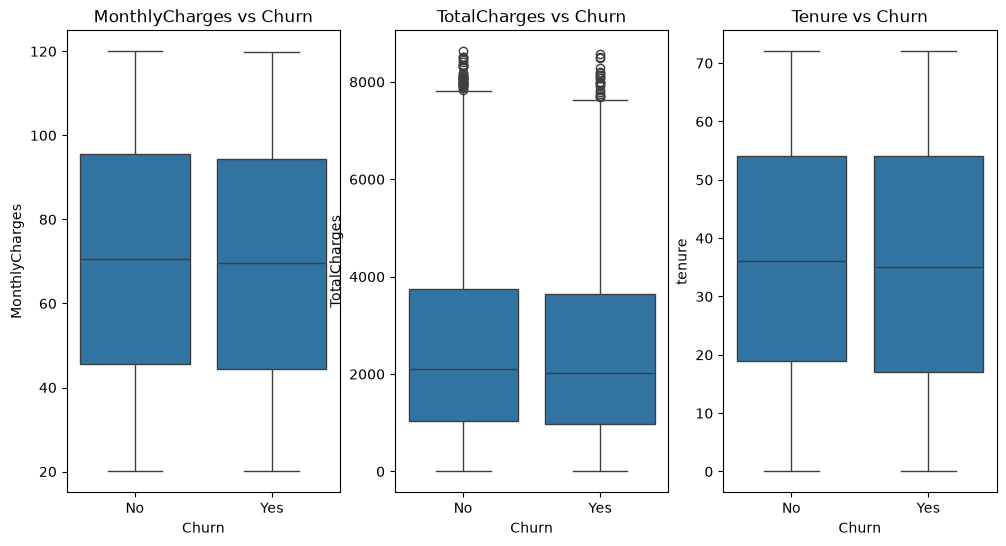

In [12]:
# boxplots das features numéricas por grupos de churn

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 6))

plt.subplot(1,3,1)
sns.boxplot(x=full_data['Churn'], y=full_data['MonthlyCharges'])
plt.title('MonthlyCharges vs Churn')

plt.subplot(1,3,2)
sns.boxplot(x=full_data['Churn'], y=full_data['TotalCharges'])
plt.title('TotalCharges vs Churn')

plt.subplot(1,3,3) 
sns.boxplot(x=full_data['Churn'], y=full_data['tenure'])
plt.title('Tenure vs Churn')

Pelos boxplots, não diferença de distribuição das features numéricas entre os grupos que realizaram churn ou não, o que indica que elas provavelmente não serão muito úteis num contexto de classificação.

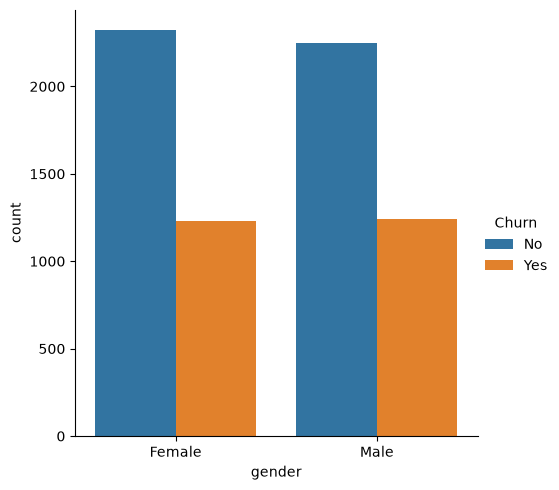

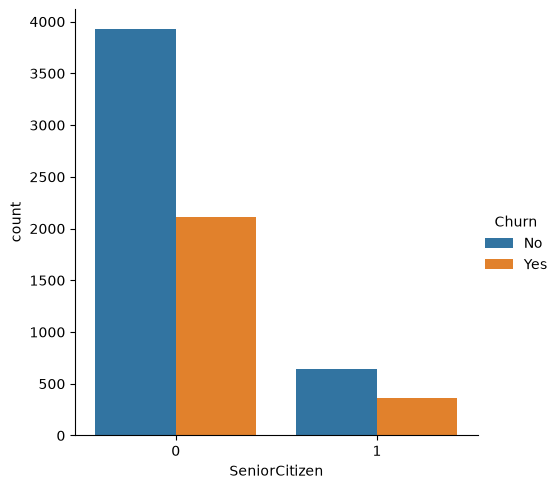

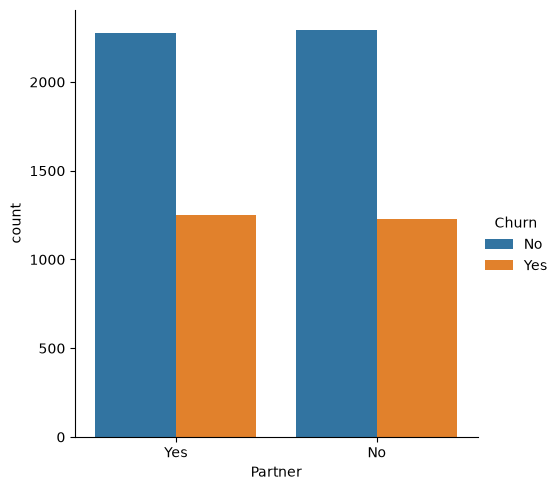

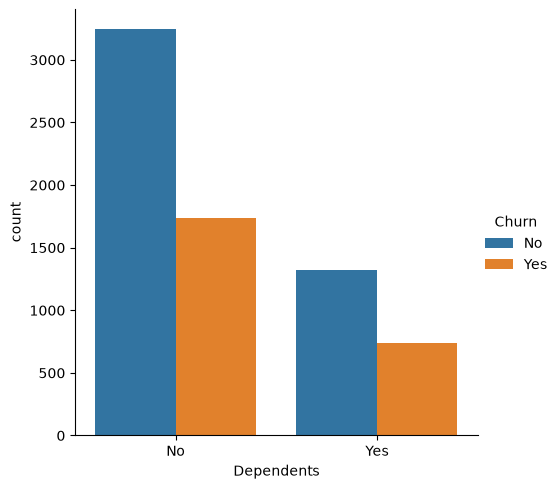

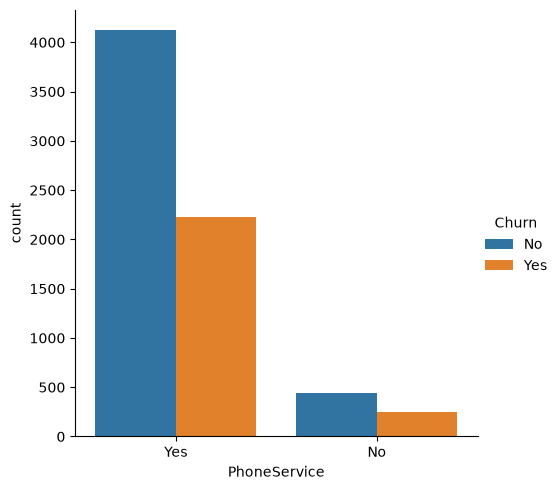

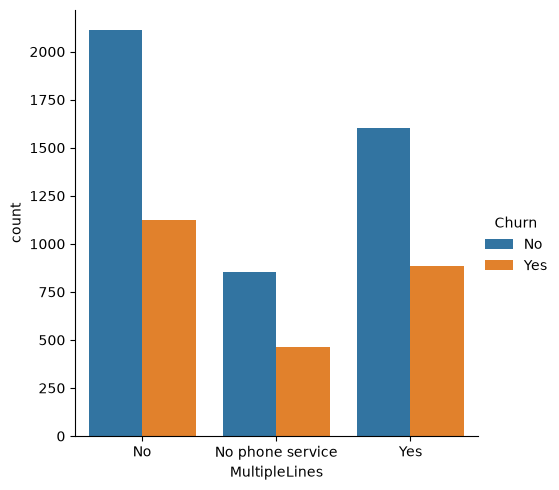

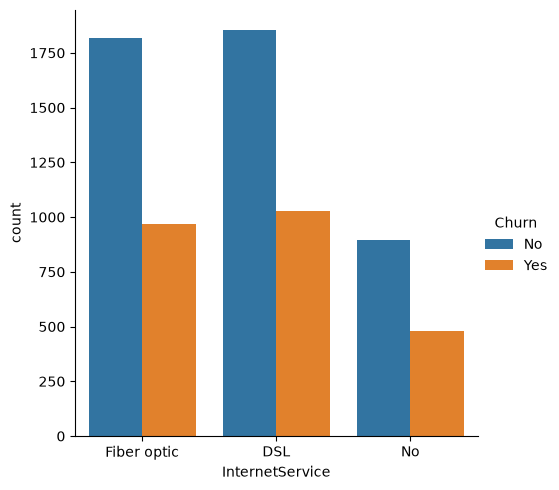

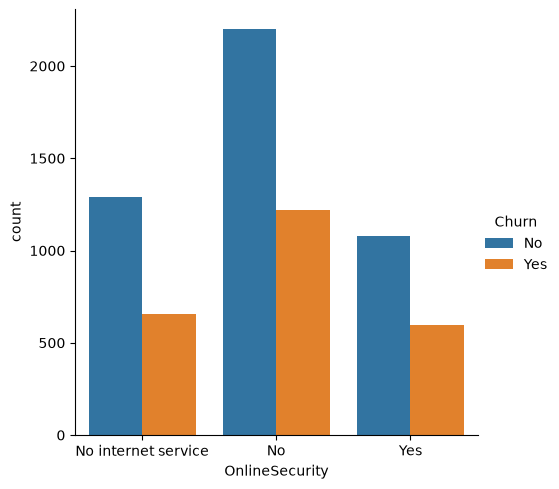

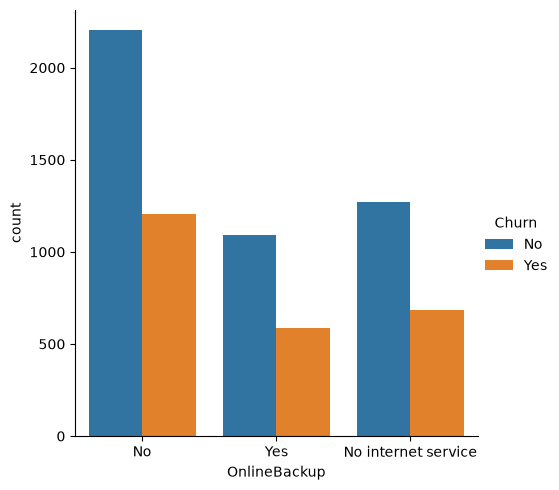

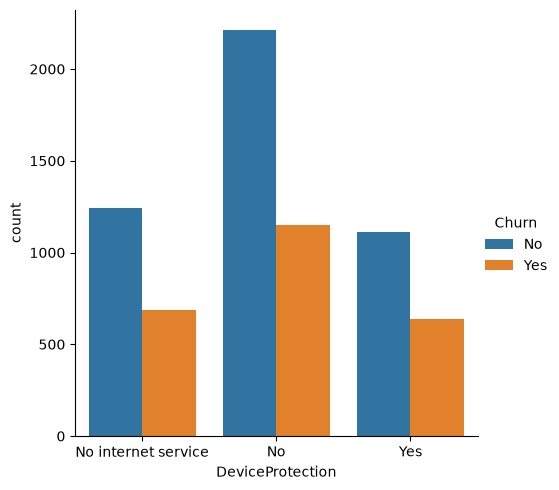

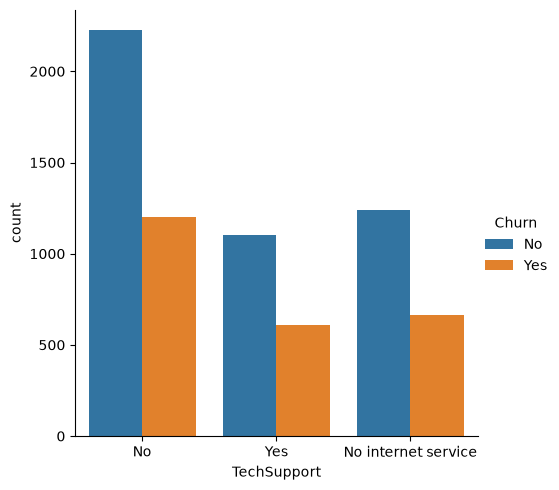

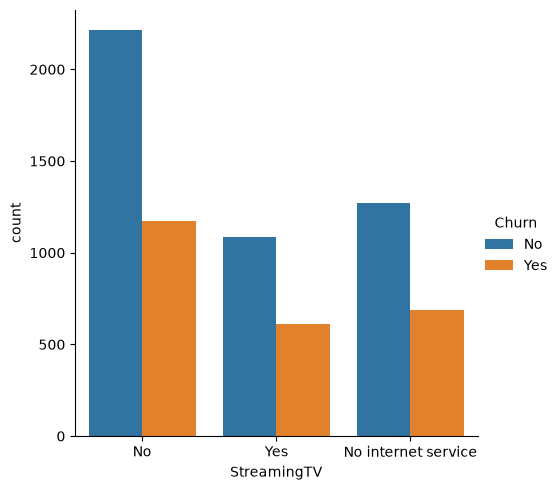

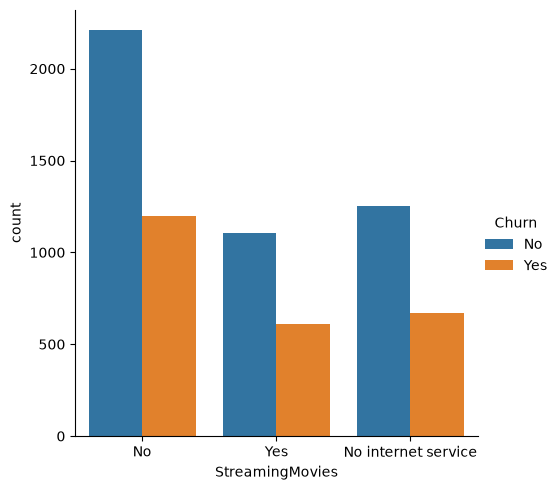

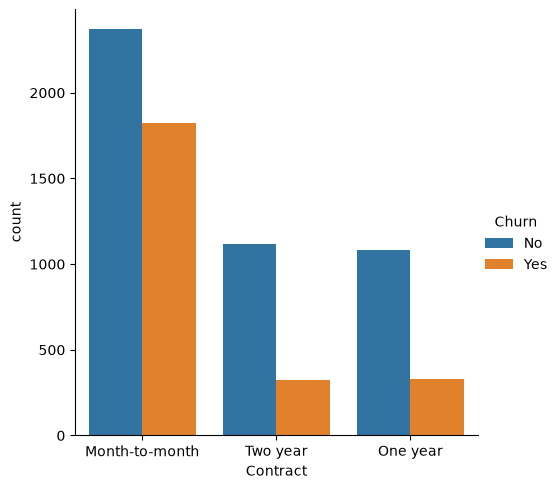

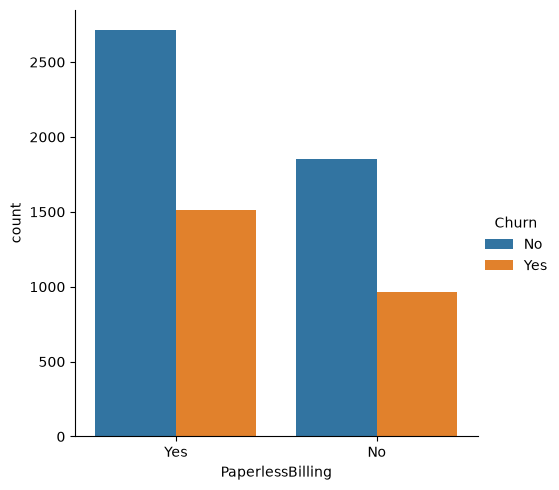

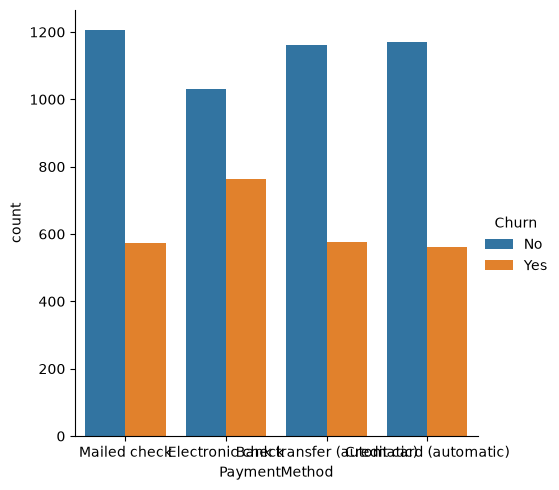

In [13]:
# barplots das features categóricas por grupos de churn
for col in categorical:
  sns.catplot(x=col, kind='count', hue='Churn', data=full_data)

Poucas features categóricas mostraram alguma diferença os grupos de churn e não churn. A principal foi, clientes que pagam mensalmente tendo uma maior chance de churn do que os pagam anual ou bianualmente, o que é um resultado esperado.

### Conclusões EDA

* Os dados são baleaceados em relação a frequência das suas categorias, não existindo categorias raras importante a serem identificadas.
* Dados isso, e ao fato de ser uma classificação ninária simples, a critério principal a ser considerado será a AUCROC.
* A mairia das features são categóricas, sendo nescessário enconding para a modelagem posterior.
* Não há valores ausentes, não sendo nescessário imputação ou descarte de dados.
* Não foram identificados outiliers na EDA.
* As features em geral não parecem ser muito informativas enquanto ao churn, o que pode levar a problemas de desempenho aos modelos ajustados posteriormente.